# Video Games Sales EDA 

## Setup and imports

Following are our libs that we will use to complete this project.

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt


np.set_printoptions(suppress = True, precision = 4) #to limit the decimal point numbers

## Loading Data **`vgsales.csv`**

In [ ]:
path = 'data/vgsales.csv'
# vgsales_csv = np.genfromtxt(path,
#                            delimiter = ',')
# this doesn't load data cause the "name" & "developer" column contain ',' within in the string and numpy can't solve it 
# since we have decided not to use pandas on this project we will use pure python csv.reader

### Attempt 2 to load data using csv reader

In [46]:
import csv
#this will be use to parse the csv without using higher libs 

In [10]:
#since we will be creating a hetrogenous large array from the csv.reader we have to define the dtypes 
my_dtypes = [
             ('platform', 'U100'),
             ('genre', 'U100'),
             ('na_sales', 'float32'),
             ('eu_sales', 'float32'),
             ('jp_sales', 'float32'),
             ('other_sales', 'float32'),
             ('global_sales', 'float32')
            ]

In [11]:
data_list =[]
#data-list will store the tuples that will be created by the loop which we will use to get data from csv reader
#then we will create array from this data-list 

##### The following code is very large but its very simple 

1. Load `vgsales.csv`using `csv.reader` then skip the header cause we don't need it
2. The `csv.reader` will give us a list that will conatins rows
3. From each row we have to select a data point of the index number of a preffered column defined in the `vgsales.csv`
4. This will create `tuples` of our desired columns
5. Then we will `append` the tuples to the `data_list` variable


In [47]:
#following is the standard way of loading csv using csv.reader
with open(path, mode='r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader) #skip header
    for row in reader:
        try:        
            platform = row[1]
            genre = row[3]
            if not platform:                # platform/genre have missing values that will be replaced with 'Unknown'
                platform = 'Unknown'
            if not genre:
                genre = 'Unknown'            
            na_sales = float(row[5])       # we have to change the dtype of sales columns from str to floats
            eu_sales = float(row[6])
            jp_sales = float(row[7])
            other_sales = float(row[8])
            global_sales = float(row[9])      
            data_list.append(
                (platform, genre, na_sales, eu_sales, 
                 jp_sales, other_sales, global_sales)
            )           
        except (ValueError, IndexError):
            # This skips rows that are empty 
            pass

In [13]:
vgsales_array = np.array(data_list, dtype = my_dtypes)

In [14]:
vgsales_array[:5]

array([('Wii', 'Sports', 41.36, 28.96,  3.77, 8.45, 82.53),
       ('NES', 'Platform', 29.08,  3.58,  6.81, 0.77, 40.24),
       ('Wii', 'Racing', 15.68, 12.76,  3.79, 3.29, 35.52),
       ('Wii', 'Sports', 15.61, 10.93,  3.28, 2.95, 32.77),
       ('GB', 'Role-Playing', 11.27,  8.89, 10.22, 1.  , 31.37)],
      dtype=[('platform', '<U100'), ('genre', '<U100'), ('na_sales', '<f4'), ('eu_sales', '<f4'), ('jp_sales', '<f4'), ('other_sales', '<f4'), ('global_sales', '<f4')])

In [15]:
platforms = vgsales_array['platform']

In [16]:
np.unique(platforms)

array(['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG',
       'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP',
       'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360',
       'XB', 'XOne'], dtype='<U100')

In [17]:
genre = vgsales_array['genre']

In [18]:
np.unique(genre)

array(['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle',
       'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports',
       'Strategy', 'Unknown'], dtype='<U100')

**We have successfully load the desired data**

### Exploring the `Genre` to find the Top three Genres

In [19]:
unique_genre, counts = np.unique(genre, return_counts=True)
print(unique_genre, counts)

['Action' 'Adventure' 'Fighting' 'Misc' 'Platform' 'Puzzle' 'Racing'
 'Role-Playing' 'Shooter' 'Simulation' 'Sports' 'Strategy' 'Unknown'] [3370 1303  849 1750  888  580 1249 1500 1323  874 2348  683    2]


In [20]:
#for ploting 
#we have to sort it in ascending order to show the top grossing genre first and so on 
sorted_indices = np.argsort(-counts) 
sorted_genres  = unique_genre[sorted_indices]
sorted_counts   = counts[sorted_indices]

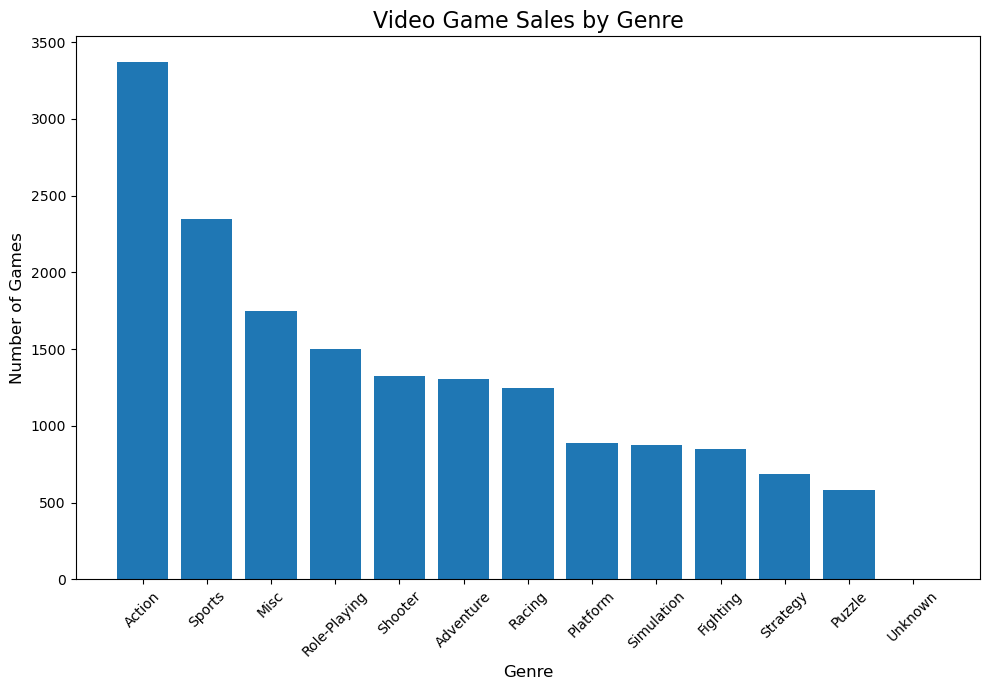

In [21]:
#this is a basic plot that will show the top genres of Video Games
plt.figure(figsize=(10, 7))
plt.bar(sorted_genres, sorted_counts)
plt.title('Video Game Sales by Genre', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('genre_sales_barchart.png')
plt.show()

### Exploring the top `genre` of `Japan`

In [22]:
#first we have to form a mask of the values in japan
jp_sales =vgsales_array['jp_sales']
print(np.sum(jp_sales))

1297.4299


#### Now to find the total sales of different genres in `Japan` 
#### As we have decided to use numpy basics only so we will have alot of `repetetive code`

In [23]:
#Action sales
action_mask = genre == 'Action'
jp_action = jp_sales[action_mask]
jp_action_sales = jp_action.sum()

In [24]:
#Sports sales
sports_mask = genre == 'Sports'
jp_sports = jp_sales[sports_mask]
jp_sports_sales = jp_sports.sum()

In [25]:
#RolePlaying sales
roleplaying_mask     = genre == 'Role-Playing'
jp_roleplaying       = jp_sales[roleplaying_mask]
jp_roleplaying_sales = jp_roleplaying.sum()


In [26]:
#misc sales
misc_mask = genre == 'Misc'
jp_misc = jp_sales[misc_mask]
jp_misc_sales = jp_misc.sum()

In [27]:
jp_top_genre = [jp_action_sales,jp_sports_sales, jp_roleplaying_sales, jp_misc_sales]
jp_top_genre_lables = ['Action', 'Sports','Role-Playing','Misc']
jp_top_genre

[np.float32(161.43999),
 np.float32(135.54001),
 np.float32(355.46),
 np.float32(108.11)]

Text(0, 0.5, 'Sales (in Millions)')

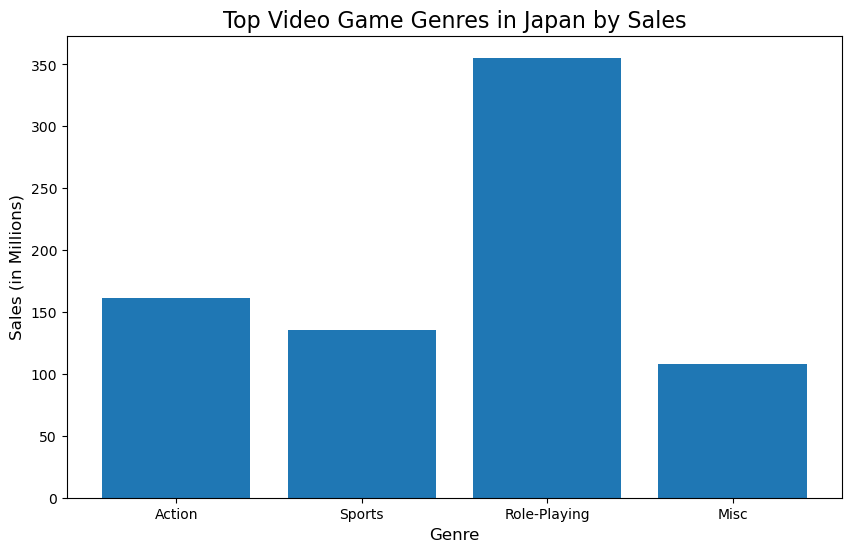

In [28]:
plt.figure(figsize=(10,6))
plt.bar(jp_top_genre_lables,jp_top_genre)
plt.title('Top Video Game Genres in Japan by Sales', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Sales (in Millions)', fontsize=12)

### Exploring the top `genre` of `North-America`

In [29]:
#first we have to form a mask of the values in japan
na_sales =vgsales_array['na_sales']
print(np.sum(na_sales))

4402.6206


In [30]:
#Action sales
action_mask = genre == 'Action'
na_action = na_sales[action_mask]
na_action_sales = na_action.sum()

In [31]:
#Sports sales
sports_mask = genre == 'Sports'
na_sports = na_sales[sports_mask]
na_sports_sales = na_sports.sum()

In [32]:
#RolePlaying sales
roleplaying_mask     = genre == 'Role-Playing'
na_roleplaying       = na_sales[roleplaying_mask]
na_roleplaying_sales = na_roleplaying.sum()


In [33]:
#misc sales
misc_mask = genre == 'Misc'
na_misc = na_sales[misc_mask]
na_misc_sales = na_misc.sum()

In [34]:
na_top_genre = [na_action_sales,na_sports_sales, na_roleplaying_sales, na_misc_sales]
na_top_genre_lables = ['Action', 'Sports','Role-Playing','Misc']
na_top_genre

[np.float32(879.00995),
 np.float32(684.43),
 np.float32(330.81),
 np.float32(407.27002)]

Text(0, 0.5, 'Sales (in Millions)')

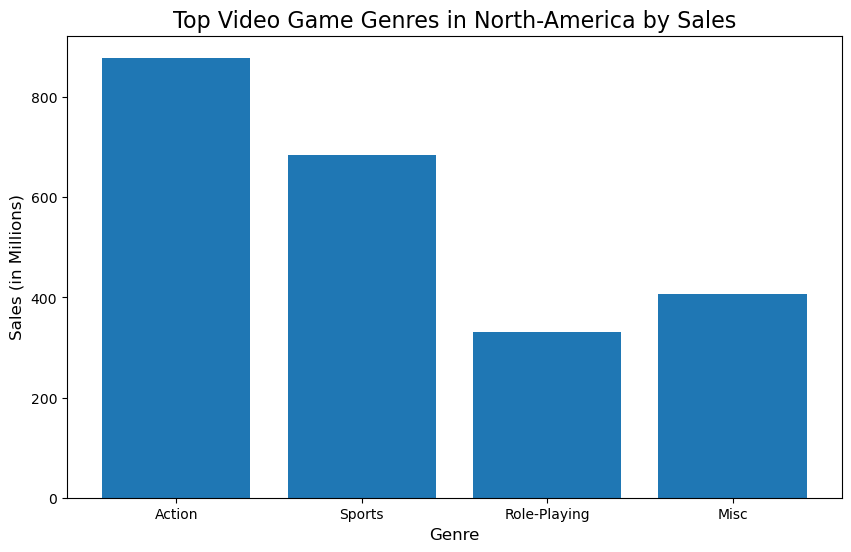

In [35]:
plt.figure(figsize=(10,6))
plt.bar(na_top_genre_lables,na_top_genre)
plt.title('Top Video Game Genres in North-America by Sales', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Sales (in Millions)', fontsize=12)

### Exploring the top `genre` of `Europe`

In [36]:
#first we have to form a mask of the values in japan
eu_sales =vgsales_array['eu_sales']
print(np.sum(eu_sales))

2424.6702


In [37]:
#Action sales
action_mask = genre == 'Action'
eu_action = eu_sales[action_mask]
eu_action_sales = eu_action.sum()

In [38]:
#Sports sales
sports_mask = genre == 'Sports'
eu_sports = eu_sales[sports_mask]
eu_sports_sales = eu_sports.sum()

In [39]:
#RolePlaying sales
roleplaying_mask     = genre == 'Role-Playing'
eu_roleplaying       = eu_sales[roleplaying_mask]
eu_roleplaying_sales = eu_roleplaying.sum()


In [40]:
#misc sales
misc_mask = genre == 'Misc'
eu_misc = eu_sales[misc_mask]
eu_misc_sales = eu_misc.sum()

In [41]:
eu_top_genre = [eu_action_sales,eu_sports_sales, eu_roleplaying_sales, eu_misc_sales]
eu_top_genre_lables = ['Action', 'Sports','Role-Playing','Misc']
eu_top_genre

[np.float32(519.13),
 np.float32(376.78998),
 np.float32(188.71),
 np.float32(212.74)]

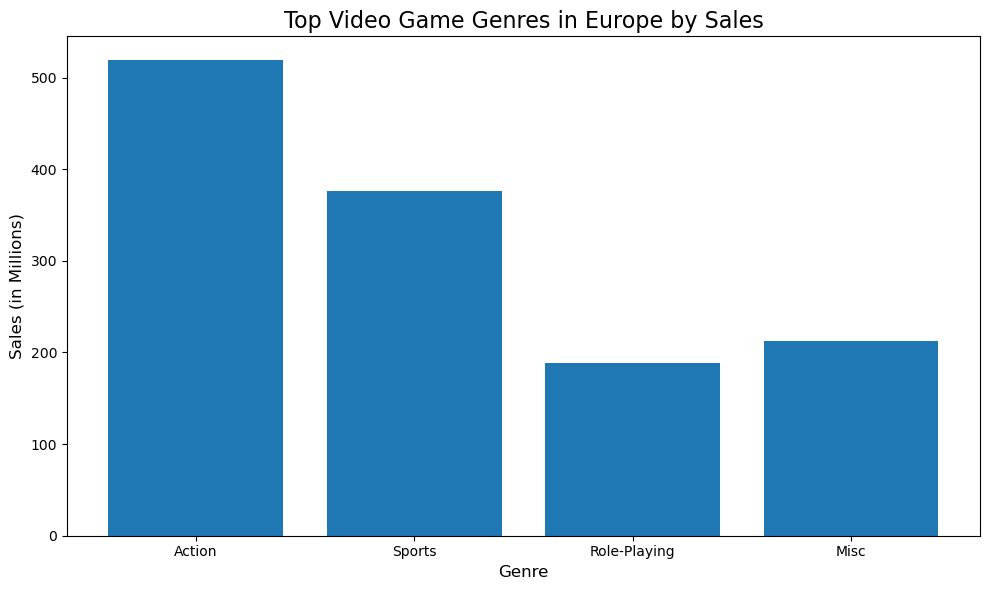

In [42]:
plt.figure(figsize=(10,6))
plt.bar(eu_top_genre_lables,eu_top_genre)
plt.title('Top Video Game Genres in Europe by Sales', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Sales (in Millions)', fontsize=12)
plt.tight_layout()

#### Plotting the `Top Genres` across different `regions`

In [43]:
genres = ['Action', 'Sports', 'Role-Playing', 'Misc']

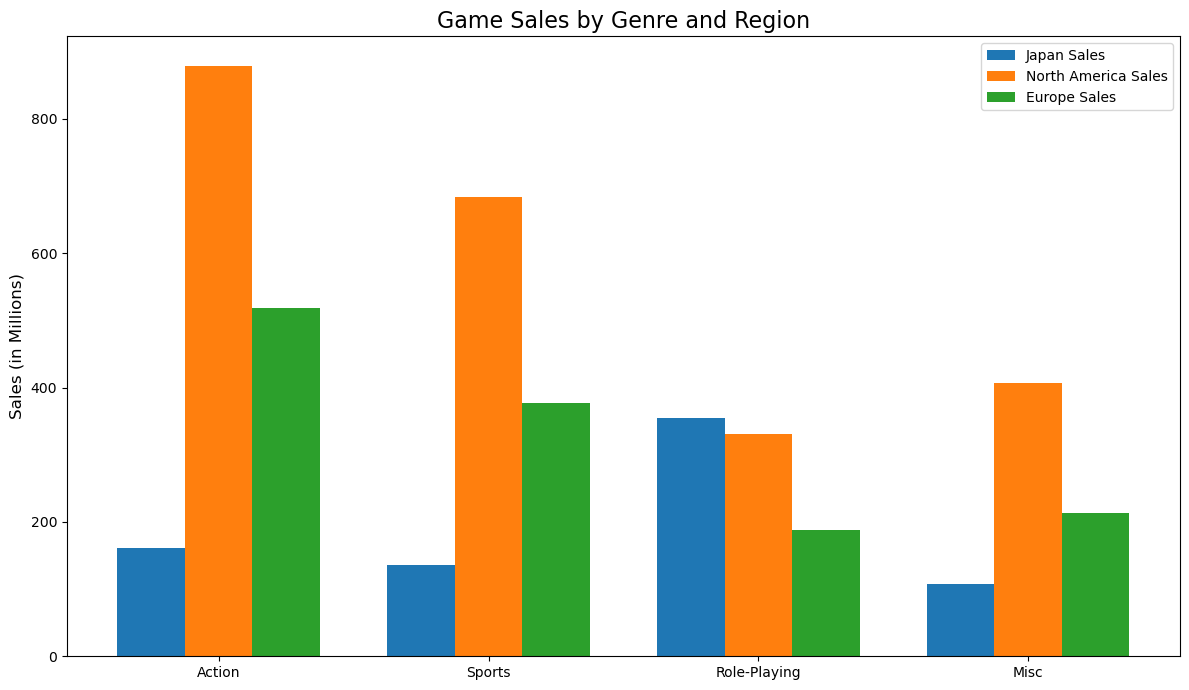

In [44]:
x_positions = np.arange(len(genres)) 
bar_width = 0.25 
plt.figure(figsize=(12, 7))
plt.bar(x_positions - bar_width, jp_top_genre, 
        width=bar_width, label='Japan Sales')
plt.bar(x_positions, na_top_genre, 
        width=bar_width, label='North America Sales')

plt.bar(x_positions + bar_width, eu_top_genre, 
        width=bar_width, label='Europe Sales')

plt.title('Game Sales by Genre and Region', fontsize=16)
plt.ylabel('Sales (in Millions)', fontsize=12)

plt.xticks(x_positions, genres)
plt.legend()
plt.tight_layout()
plt.savefig('grouped_genre_sales.png')